**This is the start of Machine Learning Course. The first few cells show how Supervised and Unsepervised learning differ and where they are used**

house_size = [  200   500  1000  3000 10000]
house_price = [  50000  120000  250000  800000 2500000]


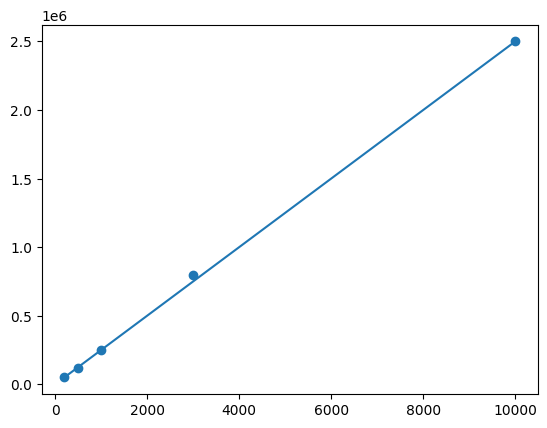

In [161]:
# introduction to supervised learning -> Regression

import matplotlib.pyplot as plt
import numpy as np
import random as rand

# inputs values x -> y
house_size = np.array([200,500,1000,3000,10000])
house_price = np.array([50000, 120000, 250000, 800000, 2500000])

print(f"house_size = {house_size}")
print(f"house_price = {house_price}")

# regression function mapping a line with slope and intercept
def regression_function (list_x):
    output = []
    for x in list_x:
        output.append(x*250 + 5)
    return output

predicted_outputs = np.array(regression_function(house_size))

# plotting function to fit data, change slope and intercept to get better fit
plt.scatter(house_size, house_price)
plt.plot(house_size, predicted_outputs)


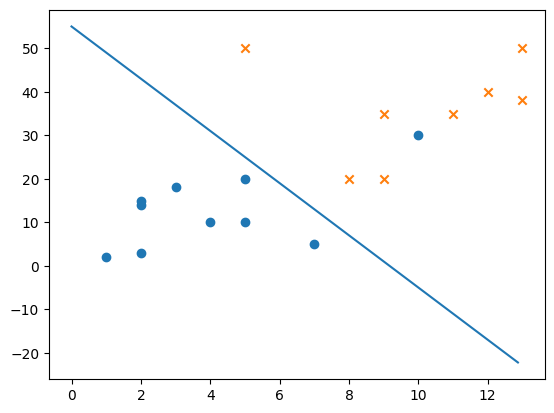

In [ ]:
# introduction to supervised learning -> Classification

# Two sets of inputs and outputs with two inputs values(x's) and 1 outputs(limited finite set y)
tumor_size_benign = np.array([2, 1, 7, 10, 4, 2, 5, 3, 5, 2])
age_benign = np.array([3, 2, 5, 30, 10, 15, 20, 18, 10, 14])

tumor_size_malignant = np.array([5, 9, 11, 13, 8, 9, 12, 13])
age_malignant = np.array([50, 20, 35, 38, 20, 35, 40, 50])

# classification funtion draws a boundary for classification(seperating the two classes)
def classification_function(list_x):
    outputs = []
    for x in list_x:
        outputs.append(x * -6 + 55)
    return outputs

list_x = []
for i in range(100):
    list_x.append(i/(100/13))
outputs = np.array(classification_function(list_x))

# plotting script
plt.scatter(tumor_size_benign, age_benign, marker = "o")
plt.scatter(tumor_size_malignant, age_malignant, marker = "x")
plt.plot(list_x, outputs)
plt.show()

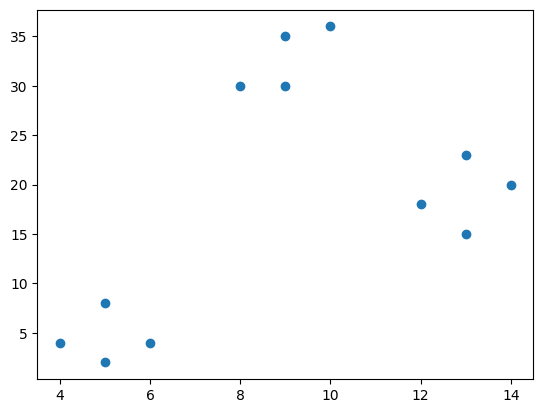

In [ ]:
# unsupervised learning -> clustering

# Here there is not "right" answer/output, just unlabeled data
age = np.array([5, 6, 5, 4, 13, 14, 13, 12, 8, 9, 10, 9])
interest = np.array([2, 4, 8, 4, 15, 20, 23, 18, 30, 35, 36, 30])

# We can plot and see general patterns/clusters that show us important information
plt.scatter(age, interest)
plt.show()

# Other Types of Unsupervised Learning involve:
# Clustering, Anomaly Detection, DImensionality Reduction

**First Python/Jupyter Lab**

Using Jupyter Notebook for Markdown and Python for Machine Learning. This is the industry standard that is used for experiments and such

**Linear Regression & Cost Functions**
- Learn about the most basic type of supervised regression learning -> Linear regression

- Learn how to train machine learning algorithms by showing them how to get to the right answer -> Cost Functions

x_train = [2000 2100 2300 2414 2131 1242 2342 5435 5312 3564 4785 2453 3645 3634
 3000 3423 2423 3456 4345 4534]
y_train = [5000 5604 6465 6435 6455 3546 4643 8688 9656 7558 8688 4564 4675 5643
 5000 5342 4352 5673 6244 6532]
m = 20


<function matplotlib.pyplot.show(close=None, block=None)>

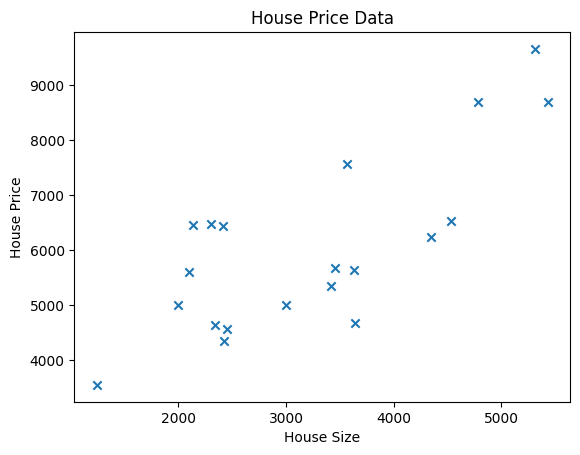

In [40]:
# Input Data for Linear Regression

x_train = np.array([2000, 2100, 2300, 2414, 2131, 1242, 2342, 5435, 5312, 3564, 4785, 2453, 3645, 3634, 3000, 3423, 2423, 3456, 4345, 4534])
y_train = np.array([5000, 5604, 6465, 6435, 6455, 3546, 4643, 8688, 9656, 7558, 8688, 4564, 4675, 5643, 5000, 5342, 4352, 5673, 6244, 6532])

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

m = len(x_train)

print(f"m = {m}")

plt.title("House Price Data")
plt.ylabel("House Price")
plt.xlabel("House Size")
plt.scatter(x_train, y_train, marker="x")
plt.show

In [ ]:
# Implementing predictive function
def f_wb(x, w, b):
    """
    Univariate linear regression function
    x = Input
    w = weight
    b = bias
    """
    m = len(x)
    f_wb = np.zeros(m)

    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb

<function matplotlib.pyplot.show(close=None, block=None)>

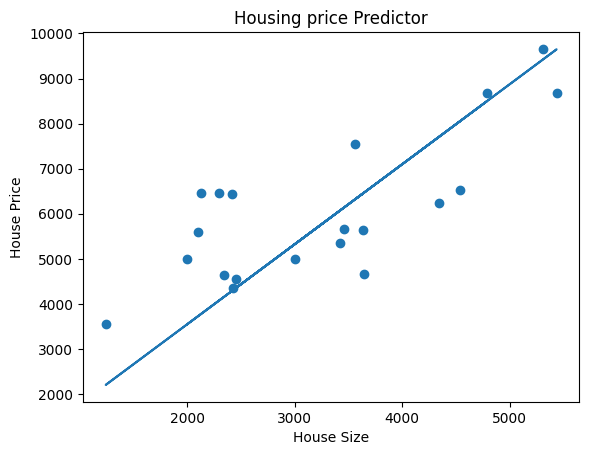

In [159]:
# test predictive function with plotting
w_test = 1.775
b_test = 0
tmp_f_wb = f_wb(x_train, w_test, b_test)

plt.plot(x_train, tmp_f_wb)
plt.scatter(x_train, y_train)
plt.title("Housing price Predictor")
plt.ylabel("House Price")
plt.xlabel("House Size")
plt.show

In [51]:
# Cost Function Definition -> Squared Error Cost Function

def J(x, y, w, b):
    '''
    m                     = Size of dataset
    y_hat[i] - y[i]       = absolute error between predicted and actual on 1 training example
    (y_hat[i] - y[i])^2   = Squared error so that negative error(y_hat < y) and positive error(y_hat > y) do not cancel
    for i in range(m)     = Sum squared error over all training examples
    error *= (1/(2*m))    = Normalize the error based on the size of the training dataset so it does not grow just because of more training values
    '''
    m = len(x)
    error = 0
    y_hat = f_wb(x, w, b)
    for i in range(m):
        error += (y_hat[i] - y[i])**2
    error *= (1/(2*m))
    return error

print(f'Cost function initial value = {J(x_train, y_train, w, b)}')

Cost function initial value = 1219161.625


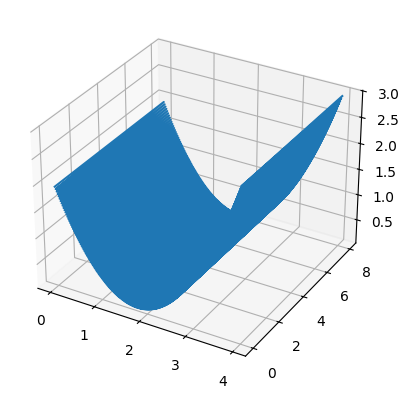

In [61]:
# Mapping the cost function in 3d with both parameters. The minimum of this is where the values of w and b provide the best model(minimal loss)
cost_values = []
w_s = []
b_s = []

for i in range(200):
    for j in range(200):
        w_s.append(i/50)
        b_s.append(j/25)
        cost_values.append(J(x_train, y_train, w_s[-1], b_s[-1]))

cost_values = np.array(cost_values)
w_s = np.array(w_s)
b_s = np.array(b_s)

plt.figure().add_subplot(projection='3d').plot(w_s, b_s, cost_values)
plt.show()

**Gradient Descent Algorithm & Derivative**

In [ ]:
# Fundemental Definition of a derivative
def derivative(a, w, b, x, y):
    delta = 0.0001
    if a == 'w':
        der = (J(x,y,w+delta,b) - J(x, y, w, b))/delta
    else:
        der = (J(x,y,w,b+delta) - J(x, y, w, b))/delta
    return der
w = 2
b = 0

In [ ]:
# implementing Gradient Descent
def gradient_descent(x, y, w, b, alpha):
    tmp_w = w - alpha*(derivative('w', w, b, x, y))
    tmp_b = b - alpha*(derivative('b', w, b, x, y))
    w = tmp_w
    b = tmp_b
    return w,b

w,b = gradient_descent(x_train, y_train, w, b, 1e-7)
print(f"w = {w}, b = {b}")

w = 1.775606121314806, b = 0.0005552480285987258


Training Linear Regression Algorithm with Squared Error Cost Function and Batch Gradient Descent
Epoch 0 | Loss = 2784548.331772395 | w = 1.2015244279727342, b = 33.99898696499318
Epoch 1 | Loss = 968128.450898839 | w = 1.8648931876933204, b = 33.999199660170824
Epoch 2 | Loss = 912808.6408704212 | w = 1.749041934502544, b = 33.99919829286344
Epoch 3 | Loss = 911107.4524802217 | w = 1.7692742788966282, b = 33.99923430959682
Epoch 4 | Loss = 911057.995911641 | w = 1.7657408764872238, b = 33.99926379755127
Epoch 5 | Loss = 911056.0528122071 | w = 1.7663579428417147, b = 33.999294425696476
Epoch 6 | Loss = 911056.0589062857 | w = 1.7662501680584395, b = 33.99932485471735
Epoch 7 | Loss = 911056.0371185646 | w = 1.7662689801029632, b = 33.999355318512876
Epoch 8 | Loss = 911056.0297320271 | w = 1.7662656849237395, b = 33.99938577623513
Epoch 9 | Loss = 911056.0201211729 | w = 1.766266250568093, b = 33.99941623501746
Epoch 10 | Loss = 911056.0109076421 | w = 1.7662661419546932, b = 33.99944

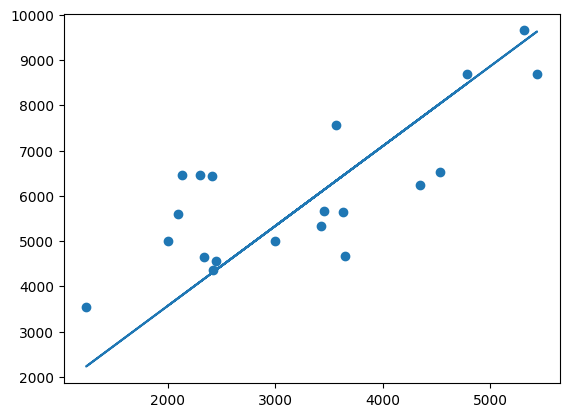

In [164]:
# Training Linear Regression Algorithm with Squared Error Cost Function and Batch Gradient Descent
w = rand.randint(0,5)
b = rand.randint(0,50)

epoch = 25

print("Training Linear Regression Algorithm with Squared Error Cost Function and Batch Gradient Descent")
for i in range(epoch):
    w,b = gradient_descent(x_train, y_train, w, b, 1e-7)
    print(f"Epoch {i} | Loss = {J(x_train, y_train, w, b)} | w = {w}, b = {b}")

print(f"Final Linear formula: f(x) = {w:.2f}x + {b:.2f}")
plt.scatter(x_train, y_train)
final_line = []
for x in x_train:
    final_line.append(w*x + b)
final_line = np.array(final_line)
plt.plot(x_train, final_line)
plt.show()